In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import os
os.chdir(r"G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting")
os.getcwd()


'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

## Exponential Weighted Moving Average - showing for comparison purposes with Simple Exponential Smoothing (SES)


In [4]:
df = pd.read_csv(r'airline_passengers.csv', index_col = 'Month', parse_dates = True)

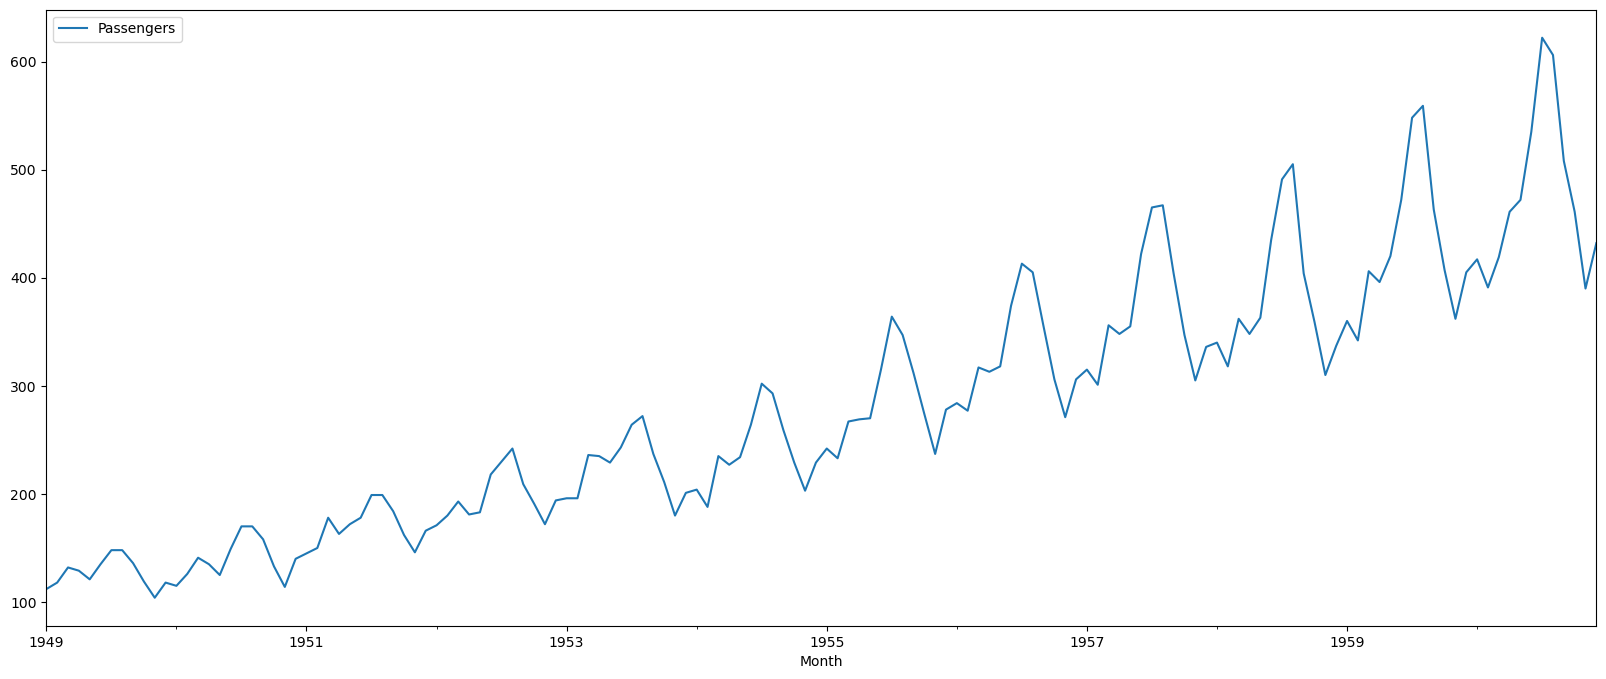

In [5]:
df.plot(figsize = (20,8));

In [6]:
alpha = 0.2

In [7]:
df['EWMA'] = df['Passengers'].ewm(alpha = alpha, adjust = False).mean()
#adjust = true assumes data is finite and adjusts the wights so that the sum of weights is always 1 - this is the default in pandas
# adjust = false assumes data series is infinite or already reached a steady state.

In [8]:
type(df['Passengers'].ewm(alpha = alpha, adjust = False))

pandas.core.window.ewm.ExponentialMovingWindow

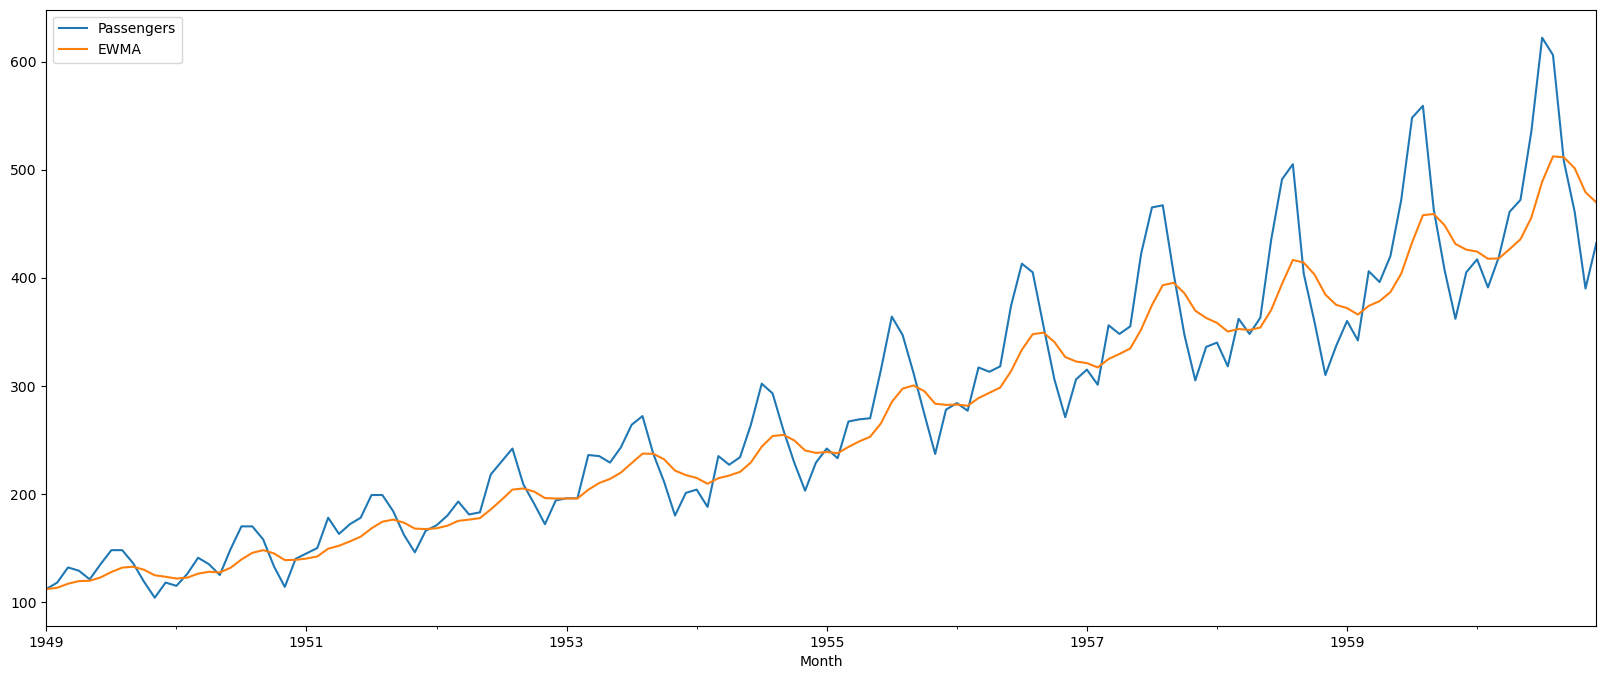

In [9]:
df.plot(figsize = (20,8));

In [10]:
# CREATING THIS MANUALLY
manual_ewma = []
for x in df['Passengers'].to_numpy():
    if len(manual_ewma)>0:
        xhat = alpha * x + (1-alpha) * manual_ewma[-1]
    else:
       xhat = x
    manual_ewma.append(xhat)
df['Manual'] = manual_ewma

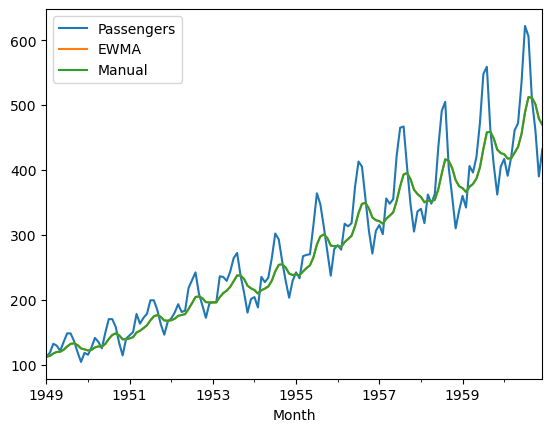

In [11]:
df.plot();

In [12]:
df.drop('Manual', axis=1, inplace = True)

In [13]:
df.head()

,Passengers,EWMA
Month,,
1949-01-01,112,112.0000
1949-02-01,118,113.2000
1949-03-01,132,116.9600
1949-04-01,129,119.3680
1949-05-01,121,119.6944


## SIMPLE EXPONENTIAL SMOOTHING (SES)

In [14]:
df.head()

,Passengers,EWMA
Month,,
1949-01-01,112,112.0000
1949-02-01,118,113.2000
1949-03-01,132,116.9600
1949-04-01,129,119.3680
1949-05-01,121,119.6944


In [16]:
ses = SimpleExpSmoothing(df['Passengers'])

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [17]:
## notice the error above - says since frequency info wasnt provided, so it uses inferred frequency

In [22]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [23]:
## notice the frequency of the above dataframe - it says freq = None

In [25]:
df.shape

(144, 2)

In [26]:
df.to_clipboard()

In [29]:
df.index.freq = 'MS'
# MS means months

In [30]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq='MS')

In [36]:
ses = SimpleExpSmoothing(df['Passengers']) ## redoing this since we changed the index frequency
# ses = SimpleExpSmoothing(df['Passengers'], initialization_method = 'legacy-heuristics') # initialization method is uses here to tell if we want to use /
# older versions of SimpleExpSmoothing

In [41]:
# we didnt get theno frequncy info provided warning 

In [37]:
alpha

0.2

In [38]:
res = ses.fit(smoothing_level = alpha, optimized = False)

In [39]:
res

In [40]:
res.predict(start = df.index[0], end = df.index[-1])

Month
1949-01-01    112.000000
1949-02-01    112.000000
1949-03-01    113.200000
1949-04-01    116.960000
1949-05-01    119.368000
                 ...    
1960-08-01    488.767616
1960-09-01    512.214093
1960-10-01    511.371274
1960-11-01    501.297019
1960-12-01    479.037615
Freq: MS, Length: 144, dtype: float64

In [43]:
df['SES'] = res.predict(start=df.index[0], end= df.index[-1])

In [44]:
res.fittedvalues # this gives prediction for insample data only

Month
1949-01-01    112.000000
1949-02-01    112.000000
1949-03-01    113.200000
1949-04-01    116.960000
1949-05-01    119.368000
                 ...    
1960-08-01    488.767616
1960-09-01    512.214093
1960-10-01    511.371274
1960-11-01    501.297019
1960-12-01    479.037615
Freq: MS, Length: 144, dtype: float64

In [45]:
## comparing these 2 if the are infact both insample data
np.allclose(df['SES'],res.fittedvalues)

True

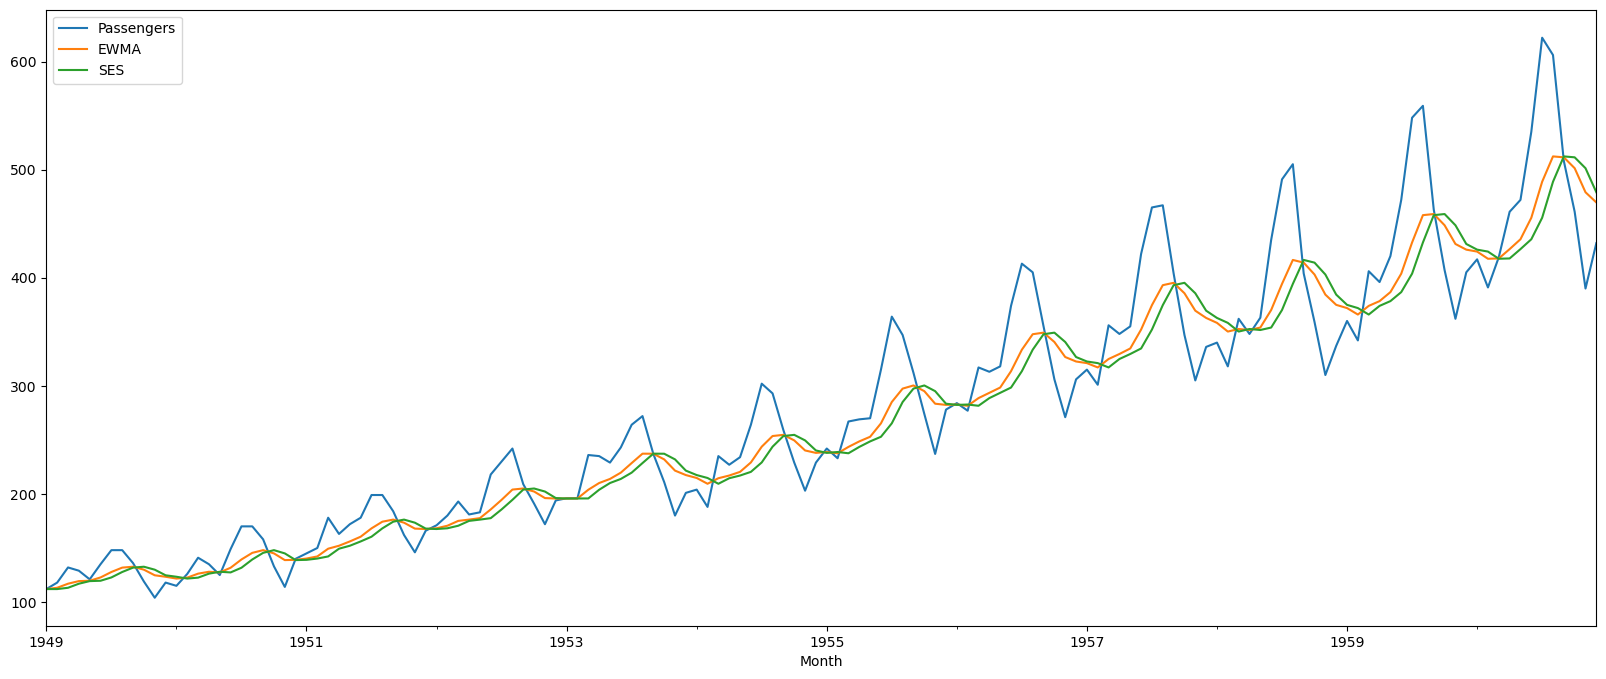

In [46]:
df.plot(figsize = (20,8));

In [49]:
# result from the pandas model EWMA and SES model from stats models is shifted by 1
## see below

In [50]:
df.head()

,Passengers,EWMA,SES
Month,,,
1949-01-01,112,112.0000,112.000
1949-02-01,118,113.2000,112.000
1949-03-01,132,116.9600,113.200
1949-04-01,129,119.3680,116.960
1949-05-01,121,119.6944,119.368


In [58]:
"""
# 1st value in both EWMA and SES are same and 2nd value in SES is repeated again, after that SES is lagging by 1 
## WHY IS SES LAGGING?
    - SES IS A FORECASTING MODEL NOT EWMA CALCULATING MODEL
    - IN THEORY, FORECAST/PREDICTION AT ANY TIME T + h, WOULD BE LEVEL AT time t, h could be any number of time steps ahead
    - here its prediction is not a constant line because it is insample data, for any out of sample data (test data), final level calculated will 
    - be the forercast or prediction for rest of time steps ahead - meaning horizontal line
"""

'\n# 1st value in both EWMA and SES are same and 2nd value in SES is repeated again, after that SES is lagging by 1 \n## WHY IS SES LAGGING?\n    - SES IS A FORECASTING MODEL NOT EWMA CALCULATING MODEL\n    - IN THEORY, FORECAST/PREDICTION AT ANY TIME T + h, WOULD BE LEVEL AT time t, h could be any number of time steps ahead\n    - here its prediction is not a constant line because it is insample data, for any out of sample data (test data), final level calculated will \n    - be the forercast or prediction for rest of time steps ahead - meaning horizontal line\n'

In [60]:
"""
THE BELOW SHOULD NOT BE DONE SINCE SES IS CORRECT - EXPLAINED IN THE CELL ABOVE
SES MODEL SHOULD BE LAGGING BEHIND ONE TIME STEP
"""
df['SES-1'] =  df['SES'].shift(-1)

In [53]:
df.head()

,Passengers,EWMA,SES,SES-1
Month,,,,
1949-01-01,112,112.0000,112.000,112.0000
1949-02-01,118,113.2000,112.000,113.2000
1949-03-01,132,116.9600,113.200,116.9600
1949-04-01,129,119.3680,116.960,119.3680
1949-05-01,121,119.6944,119.368,119.6944


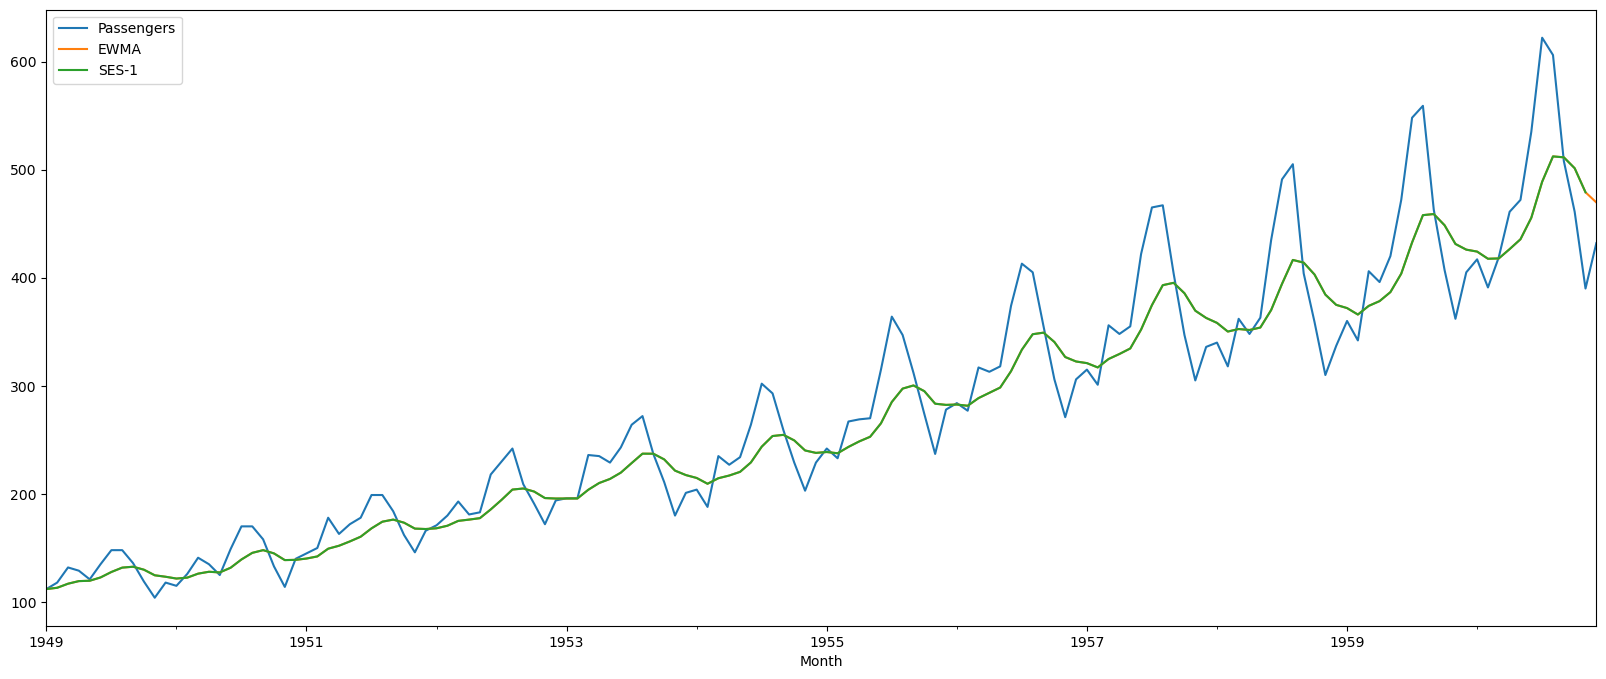

In [61]:
"""
SES-1 IS NOT THE CORRECT VALUE OF SES. original SES was infact correct only - SES is supposed to be lagging behind EWMA
"""
df[['Passengers','EWMA','SES-1']].plot(figsize = (20,8));

In [62]:
df.tail()

,Passengers,EWMA,SES,SES-1
Month,,,,
1960-08-01,606,512.214093,488.767616,512.214093
1960-09-01,508,511.371274,512.214093,511.371274
1960-10-01,461,501.297019,511.371274,501.297019
1960-11-01,390,479.037615,501.297019,479.037615
1960-12-01,432,469.630092,479.037615,NaN


## forecasting using SES
### we will split the data into train and test and do a forecast - last 12 data points set to test

In [63]:
Ntest = 12
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [66]:
ses = SimpleExpSmoothing(
    train['Passengers']
    # ,initializatio_method = 'legacy-heuristics'
)
res = ses.fit()
# """
# not passing in the argument of smoothing level and optimized. by default, optimized is set to true and we are saying ses to find out the best alpha 
# between 0 and 1 by minimizing Sum of Squared Errors SES
# """
# ses.fit(smoothing_level = alpha, optimized = False)

In [67]:
res

In [68]:
train_idx = df.index<=train.index[-1]
test_idx = df.index>train.index[-1]

In [71]:
test_idx

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

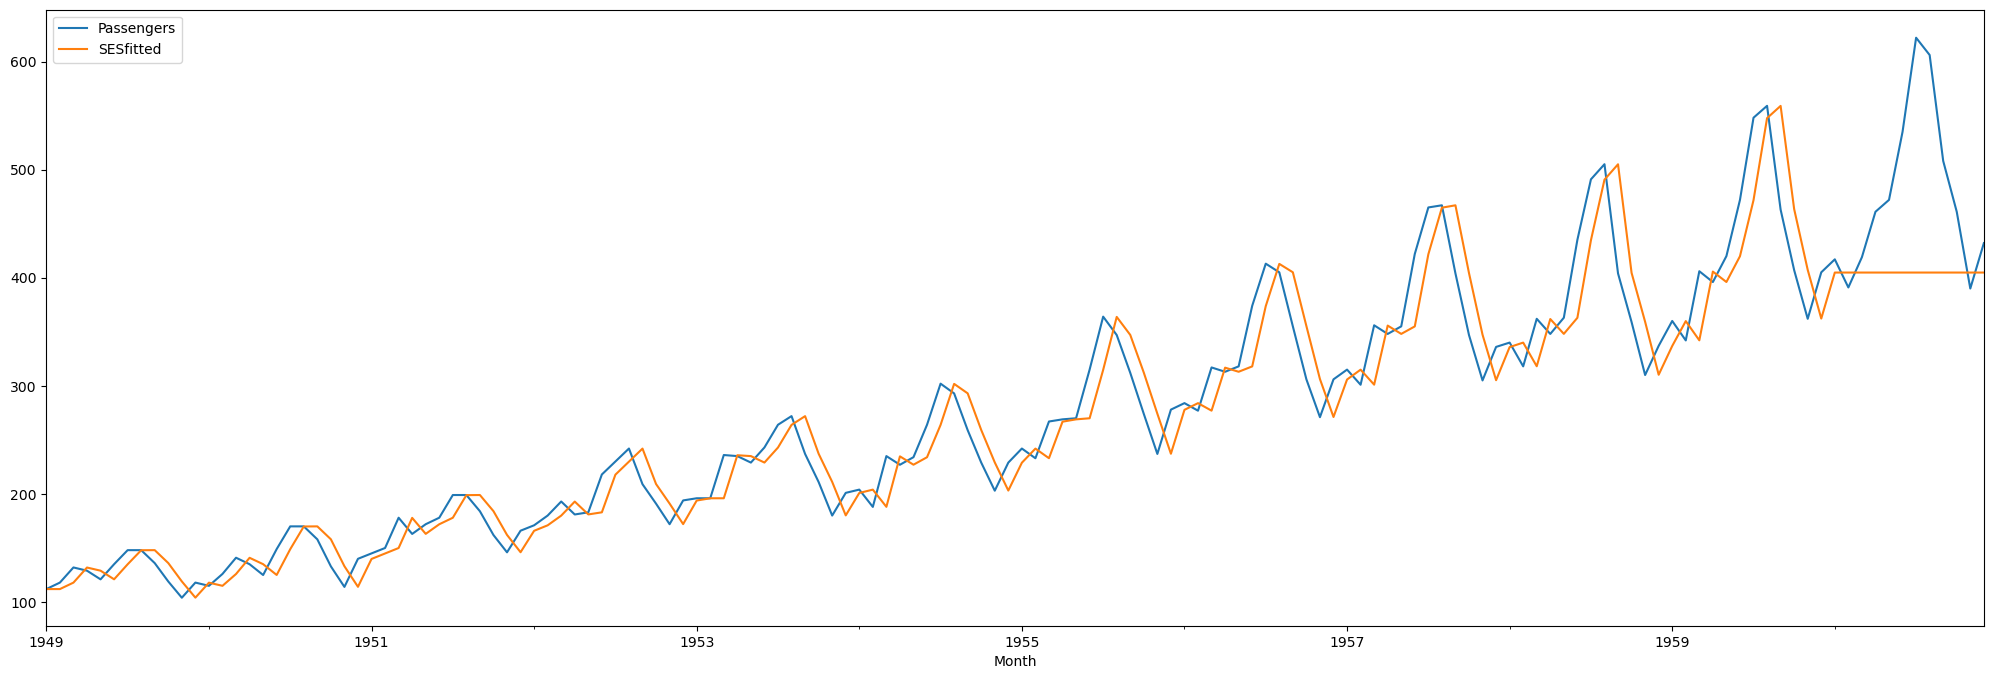

In [73]:
df.loc[train_idx, 'SESfitted'] = res.fittedvalues
df.loc[test_idx, 'SESfitted'] = res.forecast(Ntest)
df[['Passengers','SESfitted']].plot(figsize = (25,8));

In [83]:
"""
## notice that its a straight horizontal line from the beginning of test set
## also ses fitted has automatically chosen a better alpha which matches the peak very well in insample data compared to SES with manual alpha = 0.2 
## and optmized = false  
## if u look closely in the data, the ses fitted is just taking the last known value approximately, hence alpha which it found out must be very close to 1.
"""

'\n## notice that its a straight horizontal line from the beginning of test set\n## also ses fitted has automatically chosen a better alpha which matches the peak very well in insample data compared to SES with manual alpha = 0.2 \n## and optmized = false  \n## if u look closely in the data, the ses fitted is just taking the last known value approximately, hence alpha which it found out must be very close to 1.\n'

In [79]:
df.head()

,Passengers,EWMA,SES,SES-1,SESfitted
Month,,,,,
1949-01-01,112,112.0000,112.000,112.0000,112.000000
1949-02-01,118,113.2000,112.000,113.2000,112.000000
1949-03-01,132,116.9600,113.200,116.9600,117.970000
1949-04-01,129,119.3680,116.960,119.3680,131.929850
1949-05-01,121,119.6944,119.368,119.6944,129.014649


In [85]:
"""
also notice in the graph that it is lagging by 1 step from the actuals, which is fine.
bcoz, look at df.tail() where prediction starts in test set.
that 1st data in test set is the very close to the previous actual value which became the level since alpha very close to 1 .
this also proves that lagging by 1 time step is actually fine"""

'\nalso notice in the graph that it is lagging by 1 step from the actuals, which is fine.\nbcoz, look at df.tail() where prediction starts in test set.\nthat 1st data in test set is the very close to the previous actual value which became the level since alpha very close to 1 .\nthis also proves that lagging by 1 time step is actually fine'

In [86]:
df.tail(n=20)

,Passengers,EWMA,SES,SES-1,SESfitted
Month,,,,,
1959-05-01,420,386.686354,378.357943,386.686354,396.048402
1959-06-01,472,403.749084,386.686354,403.749084,419.880242
1959-07-01,548,432.599267,403.749084,432.599267,471.739401
1959-08-01,559,457.879413,432.599267,457.879413,547.618697
1959-09-01,463,458.903531,457.879413,458.903531,558.943093
1959-10-01,407,448.522825,458.903531,448.522825,463.479715
1959-11-01,362,431.218260,448.522825,431.218260,407.282399
1959-12-01,405,425.974608,431.218260,425.974608,362.226412
1960-01-01,417,424.179686,425.974608,424.179686,404.786132


In [80]:
res.params

{'smoothing_level': np.float64(0.995),
 'smoothing_trend': np.float64(nan),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(112.0),
 'initial_trend': np.float64(nan),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [82]:
'''since we are doing simple exponential smoothing which just considers the level and assumes no trend or seasonality, trend and seasonal components
are nulls above - 
also, look at the smoothing level it found out, it is very close to 1 , meaning extreme recency bias to mimic the peaks we are seeing
'''

'since we are doing simple exponential smoothing which just considers the level and assumes no trend or seasonality, trend and seasonal components\nare nulls above - \nalso, look at the smoothing level it found out, it is very close to 1 , meaning extreme recency bias to mimic the peaks we are seeing\n'

In [88]:
""" this also means that model is just doing NAIVE FORECAST - COPYING THE PREVIOUS KNOWN VALUE"""

' this also means that model is just doing NAIVE FORECAST - COPYING THE PREVIOUS KNOWN VALUE'